# 📚 Spam Classification with Naive Bayes

In [ ]:
# STEP 1: Import libraries
# These are the core tools for data handling, feature extraction, model building, and evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# STEP 2: Load dataset
spam_df = pd.read_csv("spam.csv")

In [ ]:
# STEP 3: Basic EDA (Exploratory Data Analysis)
print(spam_df.head())  # First few rows
print("++++++++++++++++")
print(spam_df.info())  # Data types and non-null counts
print("++++++++++++++++")
print(spam_df['Category'].value_counts())  # Distribution of spam vs ham

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
++++++++++++++++
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB
None
++++++++++++++++
Category
ham     4825
spam     747
Name: count, dtype: int64


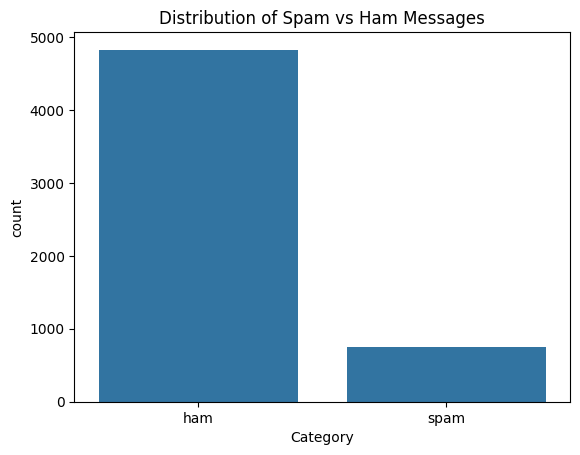

In [ ]:
# Visualization of spam vs ham distribution
sns.countplot(x='Category', data=spam_df)
plt.title("Distribution of Spam vs Ham Messages")
plt.show()

# Conclusion: If dataset is imbalanced (e.g., more ham than spam), accuracy alone is misleading.

In [ ]:
# STEP 4: Convert labels to numerical format
spam_df['spam'] = spam_df['Category'].apply(lambda x: 1 if x == 'spam' else 0)
print(spam_df.Message)
spam_df

0       Go until jurong point, crazy.. Available only ...
1                           Ok lar... Joking wif u oni...
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor... U c already then say...
4       Nah I don't think he goes to usf, he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                 Will ü b going to esplanade fr home?
5569    Pity, * was in mood for that. So...any other s...
5570    The guy did some bitching but I acted like i'd...
5571                           Rofl. Its true to its name
Name: Message, Length: 5572, dtype: str


,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will ü b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [ ]:
# STEP 5: Train-test split
x_train, x_test, y_train, y_test = train_test_split(spam_df.Message, spam_df.spam,
                                                    test_size=0.25, random_state=42)

# Conclusion: Splitting ensures we can evaluate generalization, not just memorization.

In [ ]:
# STEP 6: Convert text messages into numerical feature vectors
# CountVectorizer builds a vocabulary and transforms each message into a vector of word counts
cv = CountVectorizer()
x_train_count = cv.fit_transform(x_train.values)  # Learn vocabulary from training data and transform it
print(x_train_count.toarray())  # Show the array representation of the count vectors
print("++++++++++++++++++++")  # Transform test data using the learned vocabulary
x_train_count

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
++++++++++++++++++++


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 55858 stored elements and shape (4179, 7489)>

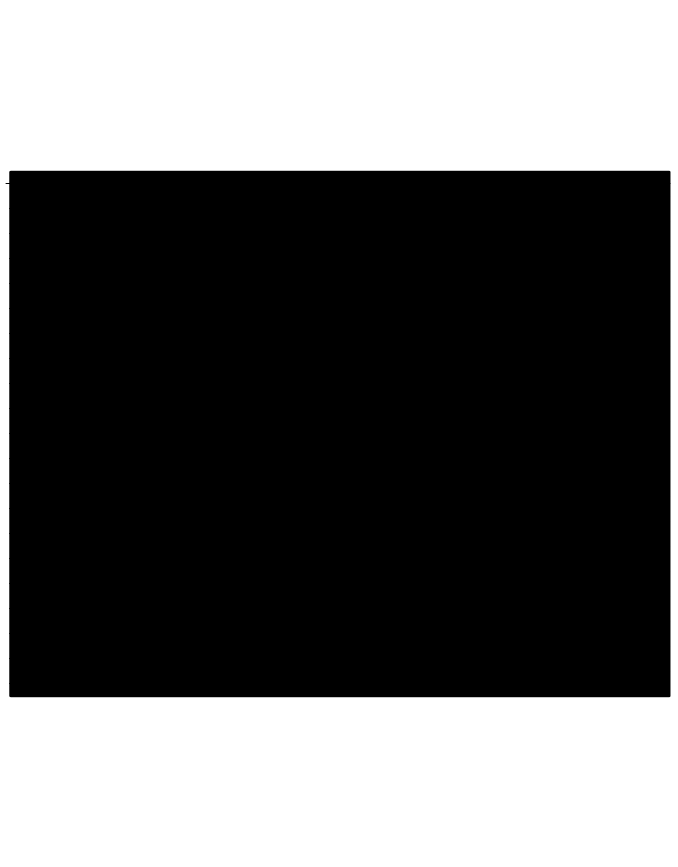

In [ ]:
# df_matrix = pd.DataFrame(x_train_count.toarray(), columns=cv.get_feature_names_out())

# # Save to PDF (via HTML rendering)
# import matplotlib.backends.backend_pdf

# pdf = matplotlib.backends.backend_pdf.PdfPages("count_matrix.pdf")
# fig, ax = plt.subplots(figsize=(8.5, 11))
# ax.axis('off')
# table = ax.table(cellText=df_matrix.values[:20], colLabels=df_matrix.columns, loc='center')
# table.scale(1, 1.5)
# pdf.savefig(fig, bbox_inches='tight')
# pdf.close()

In [ ]:
# STEP 7: Train the Naive Bayes model
# MultinomialNB is ideal for text classification with word count features
model = MultinomialNB()
model.fit(x_train_count, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
# STEP 8: Test the model on new examples
# Predict whether a new message is spam (1) or ham (0)

# Example 1: Likely ham
email_ham = ["hello do you wanna meet up for the game"]
email_ham_count = cv.transform(email_ham)  # Use transform, not fit_transform, to apply learned vocabulary
print(email_ham_count.toarray())
print("Prediction for ham:", model.predict(email_ham_count))

# Example 2: Likely spam: click reward money
email_spam = ["WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only."]
email_spam_count = cv.transform(email_spam)
print("Prediction for spam:", model.predict(email_spam_count))


[[0 0 0 ... 0 0 0]]
Prediction for ham: [0]
Prediction for spam: [1]


In [ ]:
# STEP 9: Evaluate model performance on the test set
x_test_count = cv.transform(x_test)  # Transform test messages using the same vocabulary
y_pred = model.predict(x_test_count)

# Print accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# Print confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Print precision, recall, F1-score for both classes
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Model Accuracy: 0.9885139985642498
Confusion Matrix:
 [[1203    4]
 [  12  174]]
Classification Report:
               precision    recall  f1-score   support

         Ham       0.99      1.00      0.99      1207
        Spam       0.98      0.94      0.96       186

    accuracy                           0.99      1393
   macro avg       0.98      0.97      0.97      1393
weighted avg       0.99      0.99      0.99      1393



# Custom Evaluation Function

In [ ]:
def evaluate_model(y_true, y_pred, details=True):
    '''
    y_true: Actual labels (0 for ham, 1 for spam)
    y_pred: Predicted labels by the model
    details: If True, prints detailed metrics
    '''
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    spam_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    spam_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    spam_f1 = 2 * spam_precision * spam_recall / (spam_precision + spam_recall) if (spam_precision + spam_recall) > 0 else 0

    ham_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    ham_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    ham_f1 = 2 * ham_precision * ham_recall / (ham_precision + ham_recall) if (ham_precision + ham_recall) > 0 else 0

    balanced_accuracy = (spam_recall + ham_recall) / 2

    if details:
        print(f"True Positives (Spam correctly identified): {tp}")
        print(f"False Negatives (Spam missed): {fn}")
        print(f"True Negatives (Ham correctly identified): {tn}")
        print(f"False Positives (Ham misclassified as spam): {fp}\n")

        print(f"Spam Precision: {spam_precision:.2%}")
        print(f"Spam Recall: {spam_recall:.2%}")
        print(f"Spam F1 Score: {spam_f1:.2%}\n")

        print(f"Ham Precision: {ham_precision:.2%}")
        print(f"Ham Recall: {ham_recall:.2%}")
        print(f"Ham F1 Score: {ham_f1:.2%}\n")

    print(f"Balanced Accuracy: {balanced_accuracy:.2%}")
